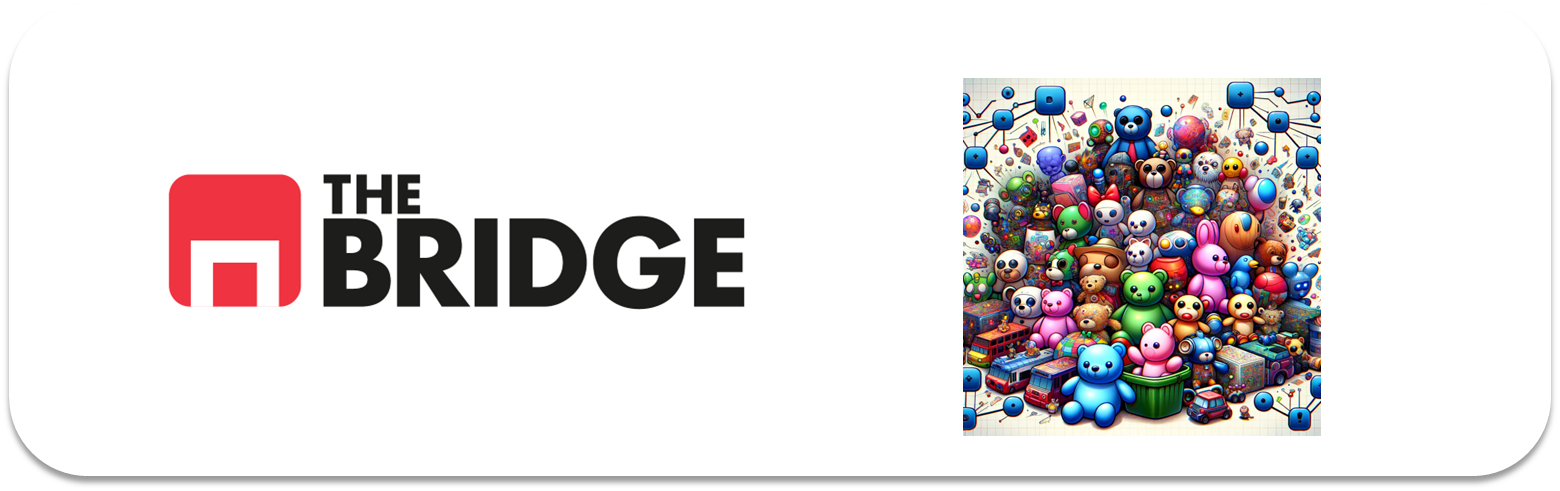

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pd.options.mode.copy_on_write = True

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vosotros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es especulativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


1. Entender el problema

Voy a usar DBSCAN porque me lo piden directamente, y también voy a aplicar un clustering jerárquico porque necesito ver cómo se relacionan entre sí los grupos que aparezcan. 


2. Cargar datos, visualizar

In [2]:
train_set = pd.read_csv("./data/empowering_drinks.csv", sep = "|")
train_set

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
...,...,...,...,...,...
148,0.493343,0.414820,-1.284344,0.009893,0.969783
149,0.332758,-0.389355,-1.344582,0.280575,2.224236
150,0.209232,0.012732,-1.354622,0.296498,1.834923
151,1.395086,1.365208,-1.274305,-0.595160,1.791666


In [3]:
train_set.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [4]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


3. MiniEDA

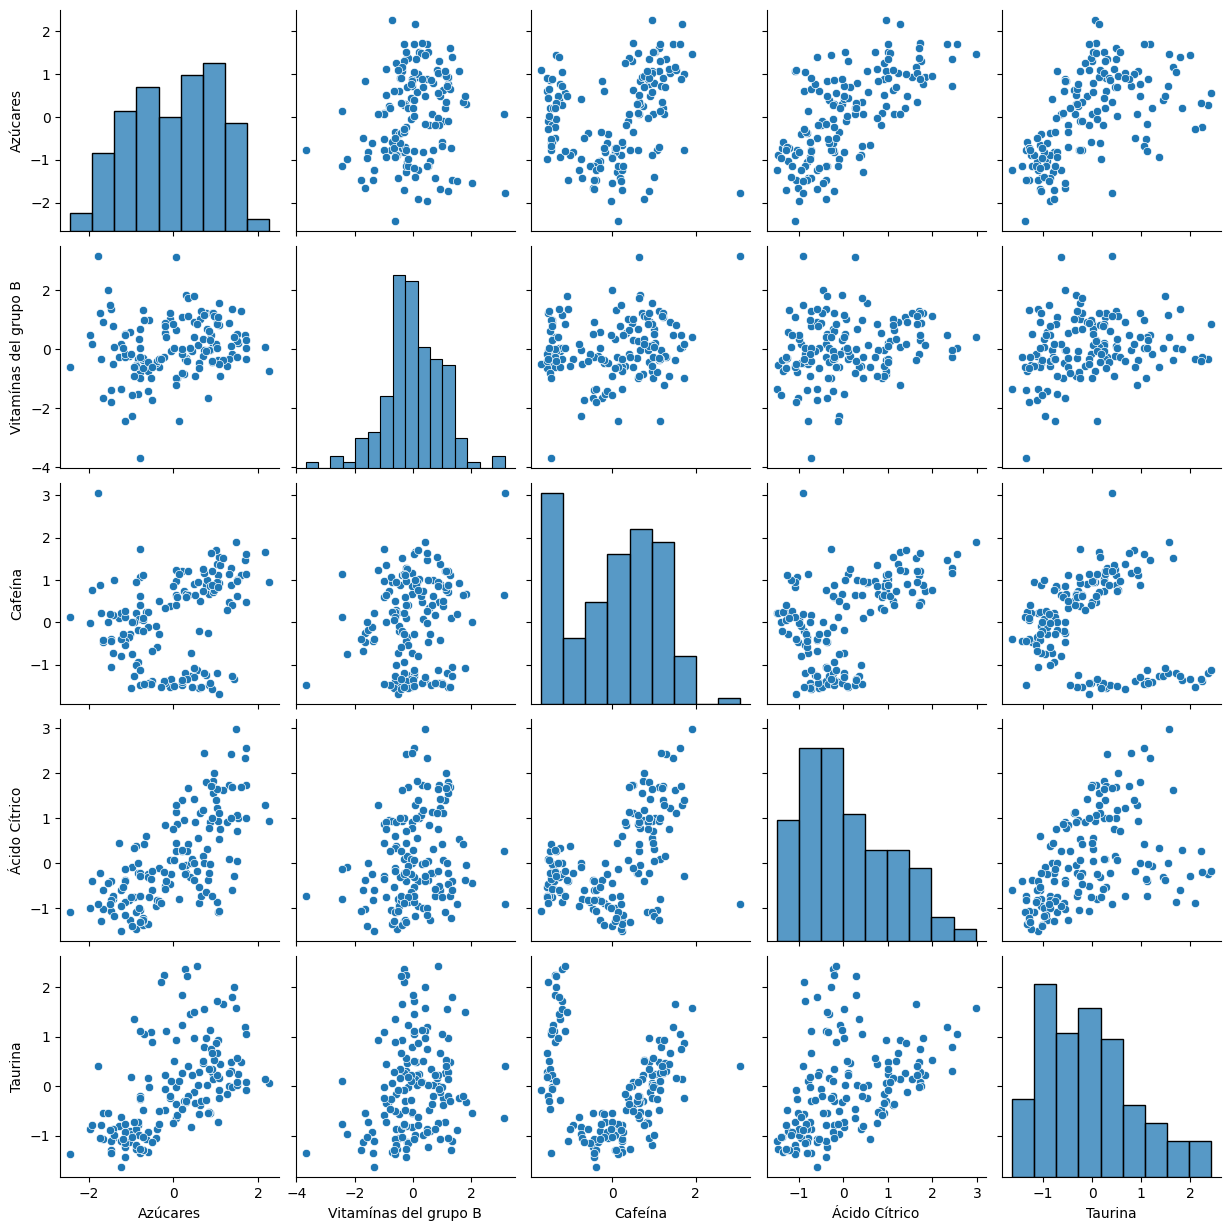

In [5]:
sns.pairplot(train_set)

En este pairplot veo que, en general, las variables no tienen relaciones fuertes entre sí porque la mayoría de los puntos están bastante dispersos. Aun así, algunas cosas se intuyen: el azúcar parece tener una ligera relación positiva con la cafeína y con la taurina, porque los puntos suben un poco hacia la derecha, aunque no es una relación clara. Las vitaminas del grupo B no muestran prácticamente ninguna relación con las otras variables, ya que los puntos están muy mezclados. El ácido cítrico tampoco parece relacionarse mucho con el resto.

In [6]:
from itertools import combinations

for variables in combinations(train_set.columns, r = 2): # itertools
    print(variables)

('Azúcares', 'Vitamínas del grupo B')
('Azúcares', 'Cafeína')
('Azúcares', 'Ácido Cítrico')
('Azúcares', 'Taurina')
('Vitamínas del grupo B', 'Cafeína')
('Vitamínas del grupo B', 'Ácido Cítrico')
('Vitamínas del grupo B', 'Taurina')
('Cafeína', 'Ácido Cítrico')
('Cafeína', 'Taurina')
('Ácido Cítrico', 'Taurina')


Azúcares vs Vitamínas del grupo B


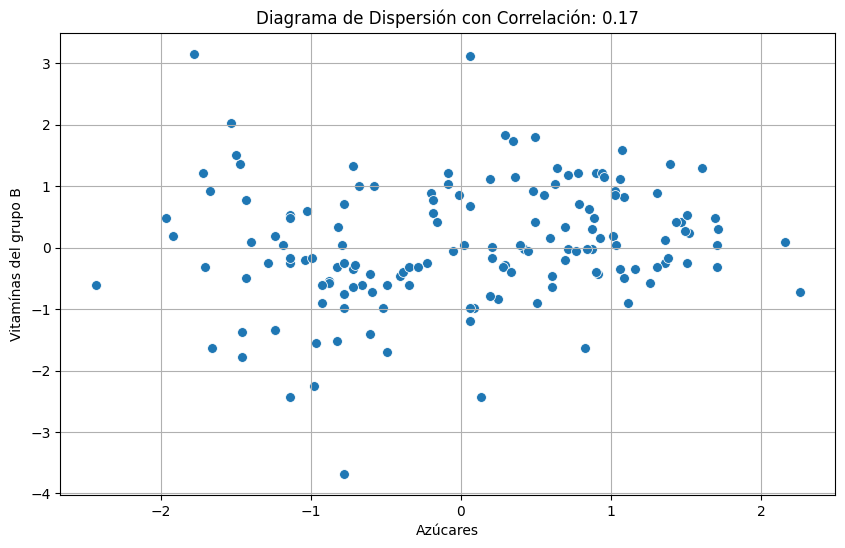

Azúcares vs Cafeína


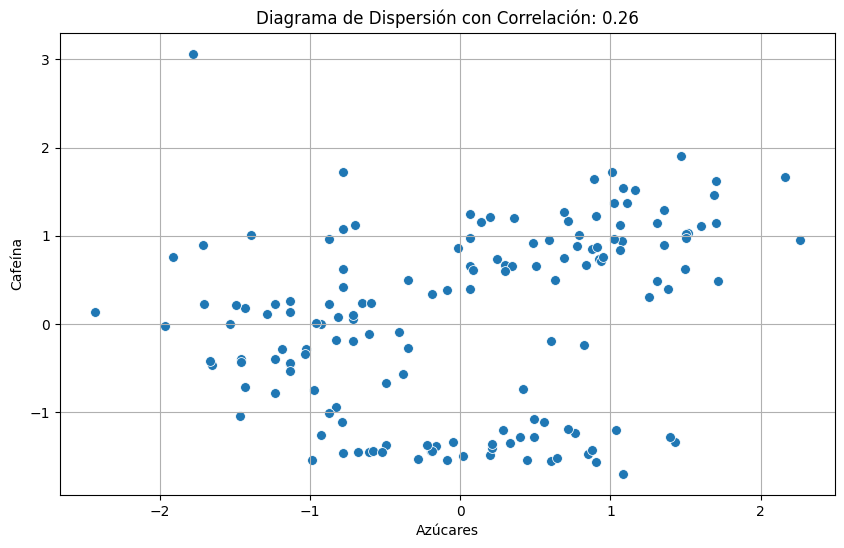

Azúcares vs Ácido Cítrico


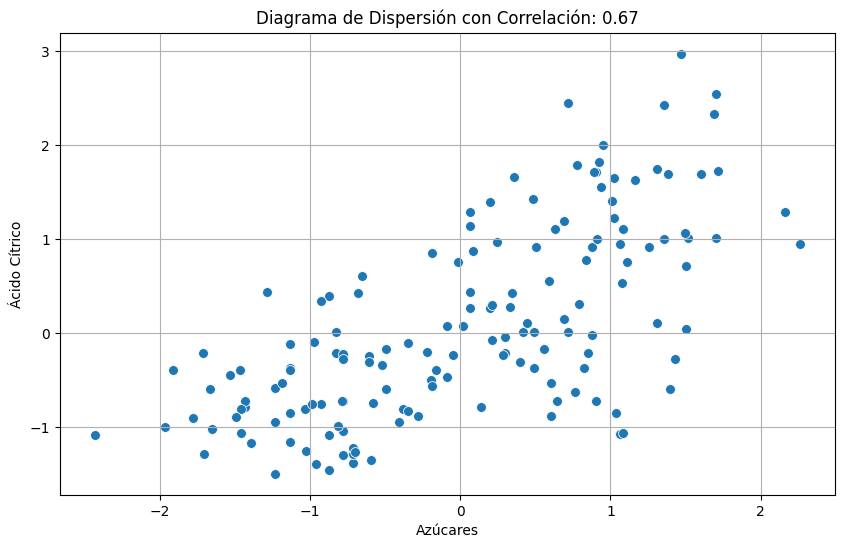

Azúcares vs Taurina


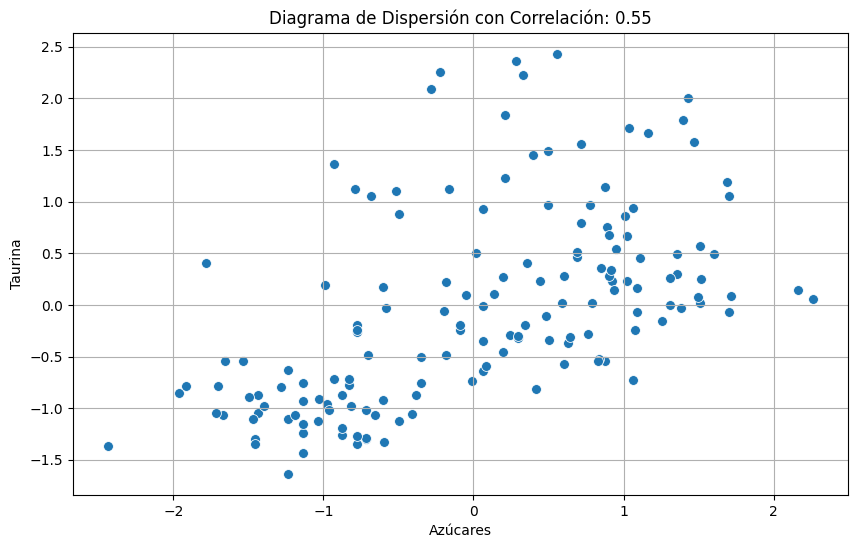

Vitamínas del grupo B vs Cafeína


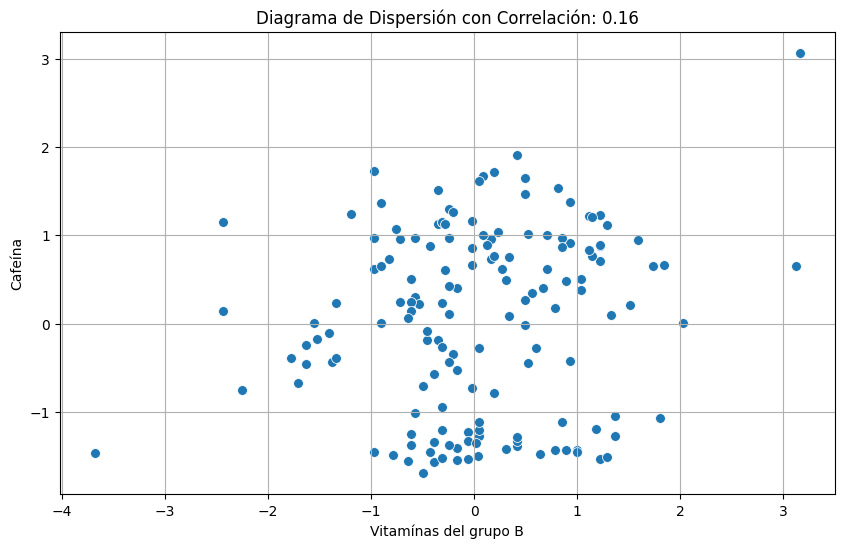

Vitamínas del grupo B vs Ácido Cítrico


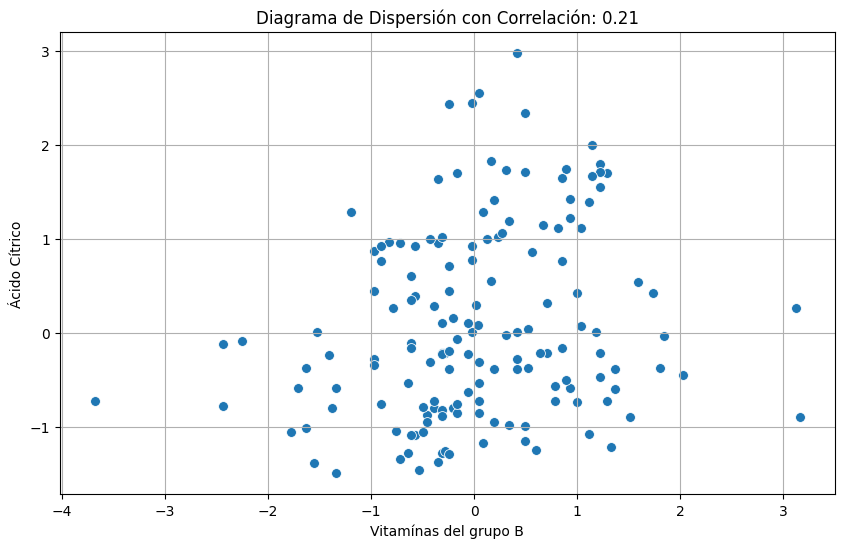

Vitamínas del grupo B vs Taurina


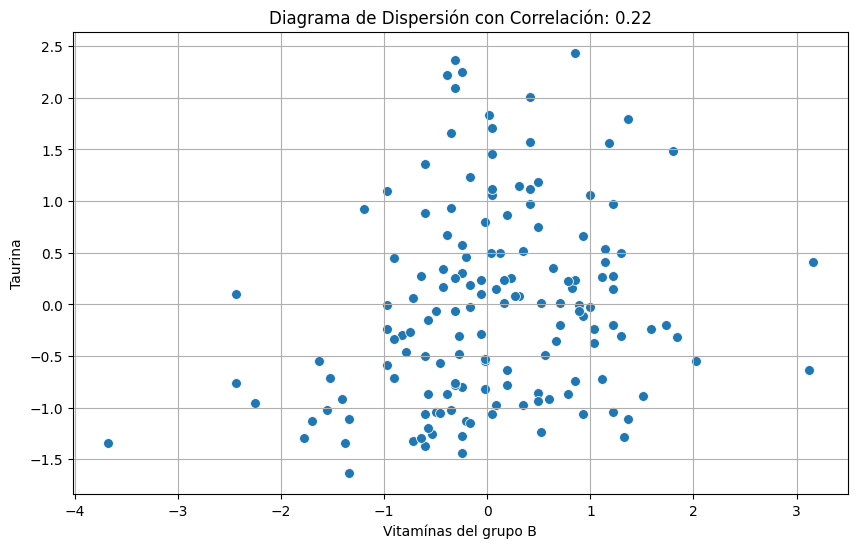

Cafeína vs Ácido Cítrico


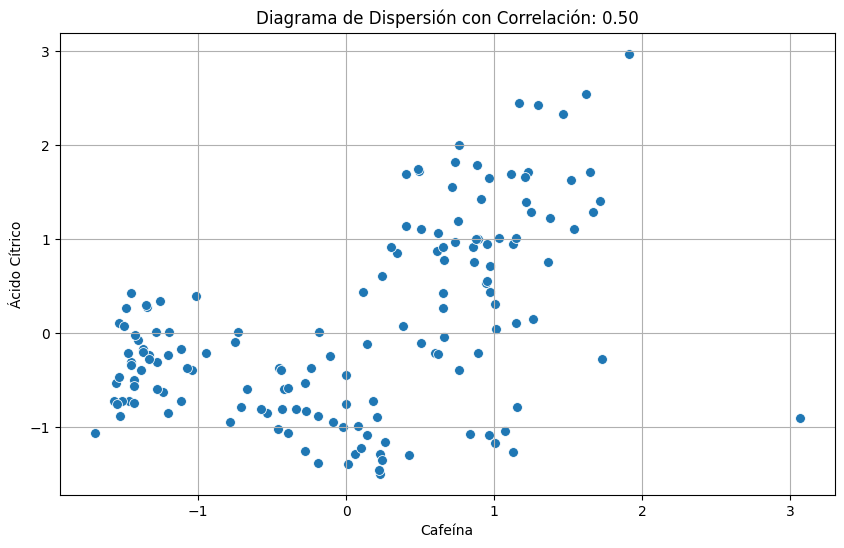

Cafeína vs Taurina


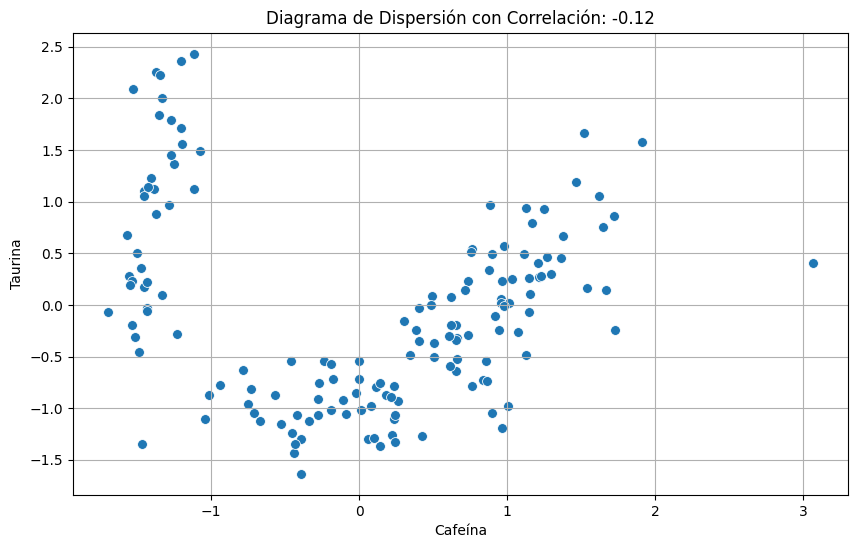

Ácido Cítrico vs Taurina


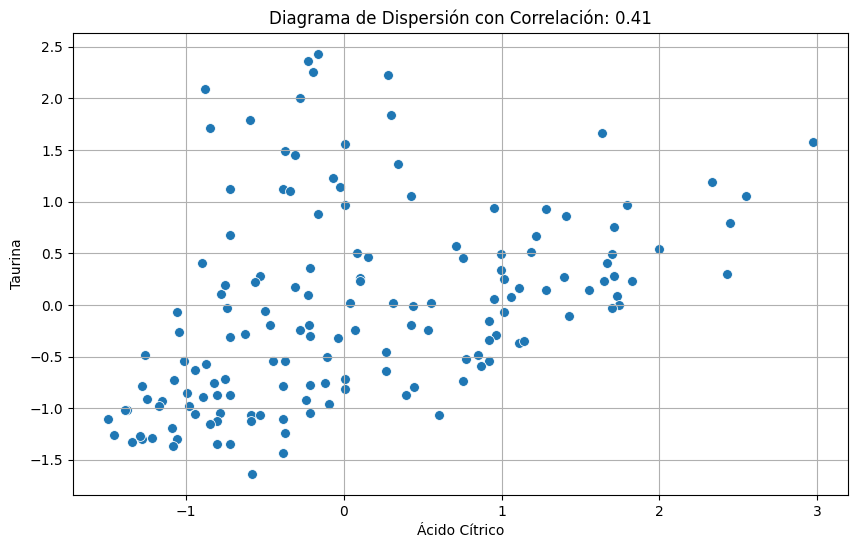

In [7]:
for x, y in combinations(train_set.columns, r = 2):
    print(f"{x} vs {y}")
    bt.grafico_dispersion_con_correlacion(train_set, x, y, mostrar_correlacion= True)

Gráfico 1: comparando los azúcares con las vitaminas del grupo B, los puntos están bastante dispersos y no forman una línea clara. Eso significa que no hay una relación fuerte entre estas dos variables. La correlación es de 0.17, que es un número pequeño, así que solo hay una relación muy débil y positiva: cuando suben los azúcares, las vitaminas suben un poquito, pero no lo suficiente como para decir que estén realmente correladas.

Gráfico 2: Los puntos están un poco inclinados hacia arriba, lo que significa que, en general, cuando hay más azúcar también suele haber un poco más de cafeína, pero la relación es muy débil. La correlación es 0.26, que es un número pequeño, así que no podemos decir que estén realmente correladas.

Gráfico 3: En este gráfico veo que los azúcares y el ácido cítrico sí parecen estar bastante relacionados. Los puntos suben de izquierda a derecha, lo que significa que cuando una bebida tiene más azúcar, normalmente también tiene más ácido cítrico. La correlación es 0.67, que es un valor bastante alto, así que aquí sí hay una relación clara y positiva. 

Gráfico 4: En este gráfico veo que los azúcares y la taurina están bastante relacionados. Los puntos suben de izquierda a derecha, lo que significa que, cuando una bebida tiene más azúcar, normalmente también tiene más taurina. La correlación es 0.55, que es un valor moderado, así que sí hay relación.

Gráfico 5: En este gráfico veo que las vitaminas del grupo B y la cafeína casi no tienen relación. Los puntos están muy dispersos y no forman ninguna forma clara. 

Gráfico 6: En este gráfico veo que las vitaminas del grupo B y el ácido cítrico casi no están relacionados. Los puntos están bastante dispersos y no forman una línea clara.

Gráfico 7: En este gráfico veo que las vitaminas del grupo B y la taurina casi no están relacionadas. Los puntos están bastante dispersos y no forman una línea clara. 

Gráfico 8: En este gráfico veo que la cafeína y el ácido cítrico sí parecen tener una relación moderada. Los puntos suben de izquierda a derecha, lo que significa que, cuando una bebida tiene más cafeína, normalmente también tiene más ácido cítrico. 

Gráfico 9: En este gráfico veo que la cafeína y la taurina prácticamente no tienen relación. Los puntos están muy dispersos y no siguen ninguna dirección clara.

Gráfico 10: En este gráfico veo que el ácido cítrico y la taurina sí parecen tener cierta relación. Los puntos suben de izquierda a derecha, lo que significa que, cuando hay más ácido cítrico, normalmente también hay más taurina.

In [8]:
variables_simples = ["Cafeína", "Taurina"]
features = train_set.columns.to_list()

4. Tratamiento de features

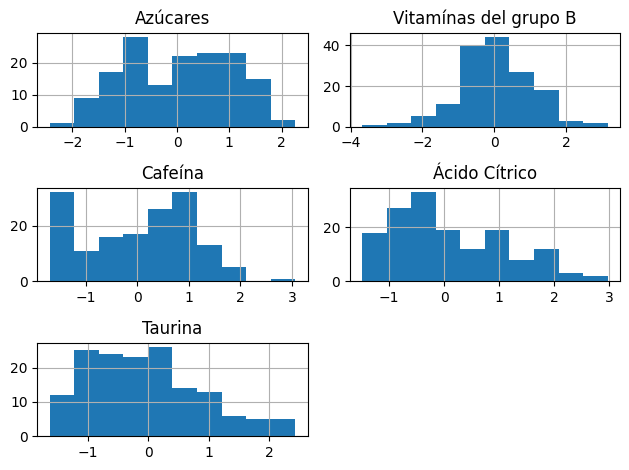

In [9]:
train_set.hist()
plt.tight_layout()

5. Ajuste de hiperparámetros (selección de eps, min_samples y de numero de clusters para el jerárquico)

##### DBSCAN

In [10]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [11]:
np.linspace(0.001, 6, 100)

array([1.00000000e-03, 6.15959596e-02, 1.22191919e-01, 1.82787879e-01,
       2.43383838e-01, 3.03979798e-01, 3.64575758e-01, 4.25171717e-01,
       4.85767677e-01, 5.46363636e-01, 6.06959596e-01, 6.67555556e-01,
       7.28151515e-01, 7.88747475e-01, 8.49343434e-01, 9.09939394e-01,
       9.70535354e-01, 1.03113131e+00, 1.09172727e+00, 1.15232323e+00,
       1.21291919e+00, 1.27351515e+00, 1.33411111e+00, 1.39470707e+00,
       1.45530303e+00, 1.51589899e+00, 1.57649495e+00, 1.63709091e+00,
       1.69768687e+00, 1.75828283e+00, 1.81887879e+00, 1.87947475e+00,
       1.94007071e+00, 2.00066667e+00, 2.06126263e+00, 2.12185859e+00,
       2.18245455e+00, 2.24305051e+00, 2.30364646e+00, 2.36424242e+00,
       2.42483838e+00, 2.48543434e+00, 2.54603030e+00, 2.60662626e+00,
       2.66722222e+00, 2.72781818e+00, 2.78841414e+00, 2.84901010e+00,
       2.90960606e+00, 2.97020202e+00, 3.03079798e+00, 3.09139394e+00,
       3.15198990e+00, 3.21258586e+00, 3.27318182e+00, 3.33377778e+00,
      

In [12]:
outlier_percent = []
experiments = {}

for min_samples in [3,5,10]:
    print(f"Min_samples = {min_samples}")
    outlier_percent = []
    for eps in np.linspace(0.001,6,100): # Genera 100 valores equidistantes entre 0.001 y 6
        
        # Creamos el modelo
        dbscan = DBSCAN(eps=eps, min_samples=min_samples) # min_samples dos veces el ´numero de features -> 2 por dimensión del hiperespacio en el que representamos el conjunto de puntos... No le des muchas vueltas es un número muy orientativo. Pero piensa que si fuera un recta querrías 2 valores, un plano 4, un cubo 6...
        dbscan.fit(train_set)
        # Registramos el porcentaje de anomalías (recuerda que se etiquetan como -1)
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        #if perc_outliers <= 10:
        #    print(perc_outliers, dbscan.labels_)
        #    print(len(dbscan.labels_))
        #    print(pd.Series(dbscan.labels_).value_counts())
        outlier_percent.append(perc_outliers)
    experiments[min_samples] = outlier_percent.copy()

Min_samples = 3
Min_samples = 5
Min_samples = 10


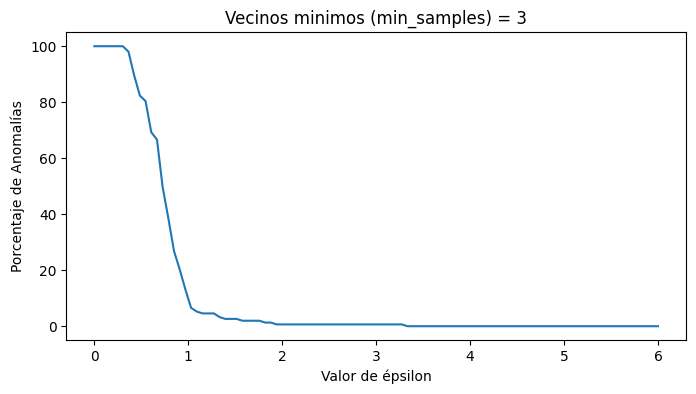

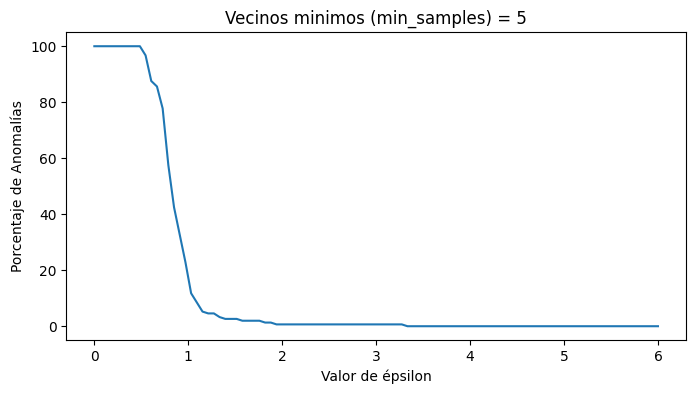

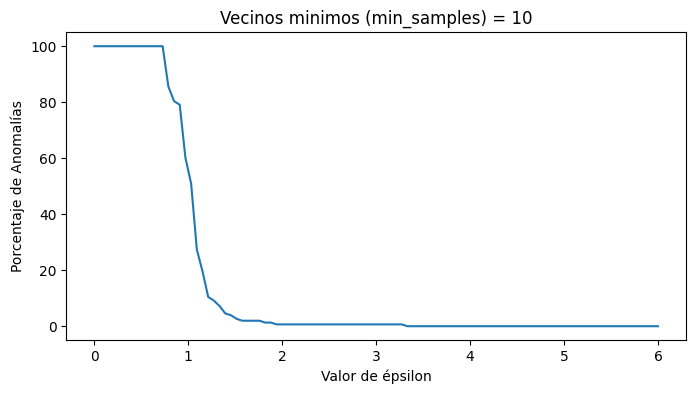

In [13]:
for min_samples in [3,5,10]:
    
    plt.figure(figsize = (8,4), dpi = 100)
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments[min_samples])
    plt.ylabel("Porcentaje de Anomalías")
    plt.xlabel("Valor de épsilon")
    plt.title(f"Vecinos minimos (min_samples) = {min_samples}")
    plt.show()

In [14]:
# Situar eps

for min_samples in [3,5,10]:
    print(f"Samples = {min_samples}:")
    for indice, valor in enumerate(np.linspace(0.001,6,100)):
        if 1.2 <= valor <= 2:
            print(f"{valor} -> {experiments[min_samples][indice]}")
    

Samples = 3:
1.2129191919191917 -> 4.57516339869281
1.2735151515151513 -> 4.57516339869281
1.334111111111111 -> 3.2679738562091503
1.3947070707070706 -> 2.6143790849673203
1.45530303030303 -> 2.6143790849673203
1.5158989898989896 -> 2.6143790849673203
1.5764949494949492 -> 1.9607843137254901
1.637090909090909 -> 1.9607843137254901
1.6976868686868685 -> 1.9607843137254901
1.758282828282828 -> 1.9607843137254901
1.8188787878787878 -> 1.3071895424836601
1.8794747474747473 -> 1.3071895424836601
1.9400707070707068 -> 0.6535947712418301
Samples = 5:
1.2129191919191917 -> 4.57516339869281
1.2735151515151513 -> 4.57516339869281
1.334111111111111 -> 3.2679738562091503
1.3947070707070706 -> 2.6143790849673203
1.45530303030303 -> 2.6143790849673203
1.5158989898989896 -> 2.6143790849673203
1.5764949494949492 -> 1.9607843137254901
1.637090909090909 -> 1.9607843137254901
1.6976868686868685 -> 1.9607843137254901
1.758282828282828 -> 1.9607843137254901
1.8188787878787878 -> 1.3071895424836601
1.879474

In [15]:
for min_samples in [3,5,10]:
    dbscan = DBSCAN(eps = 1.3, min_samples = min_samples)
    dbscan.fit(train_set)
    print(f"{min_samples} = {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters")

3 = 1 clusters
5 = 1 clusters
10 = 1 clusters


Mismo número de cluster en los tres --> Reducir eps

In [16]:
for min_samples in [3,5,10]:
    dbscan = DBSCAN(eps = 1.0, min_samples = min_samples)
    dbscan.fit(train_set)
    print(f"{min_samples} = {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters")

3 = 4 clusters
5 = 3 clusters
10 = 2 clusters


In [17]:
dbscan = DBSCAN(eps = 1.0, min_samples = 3)
dbscan.fit(train_set)
print(f"{min_samples} = {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters")

10 = 4 clusters


El modelo DBSCAN solo consigue separar los datos en 3 grupos cuando le digo que cada punto debe tener al menos 10 puntos cerca para formar un clúster. Si uso un número menor o mayor, ya no aparecen esos 3 grupos. El problema es que, con esos parámetros, DBSCAN marca más del 10% de los datos como anomalías(puntos que no pertenecen a ningún clúster).

In [18]:
train_set_clu = train_set.copy()
train_set_clu["Cluster"] = dbscan.labels_

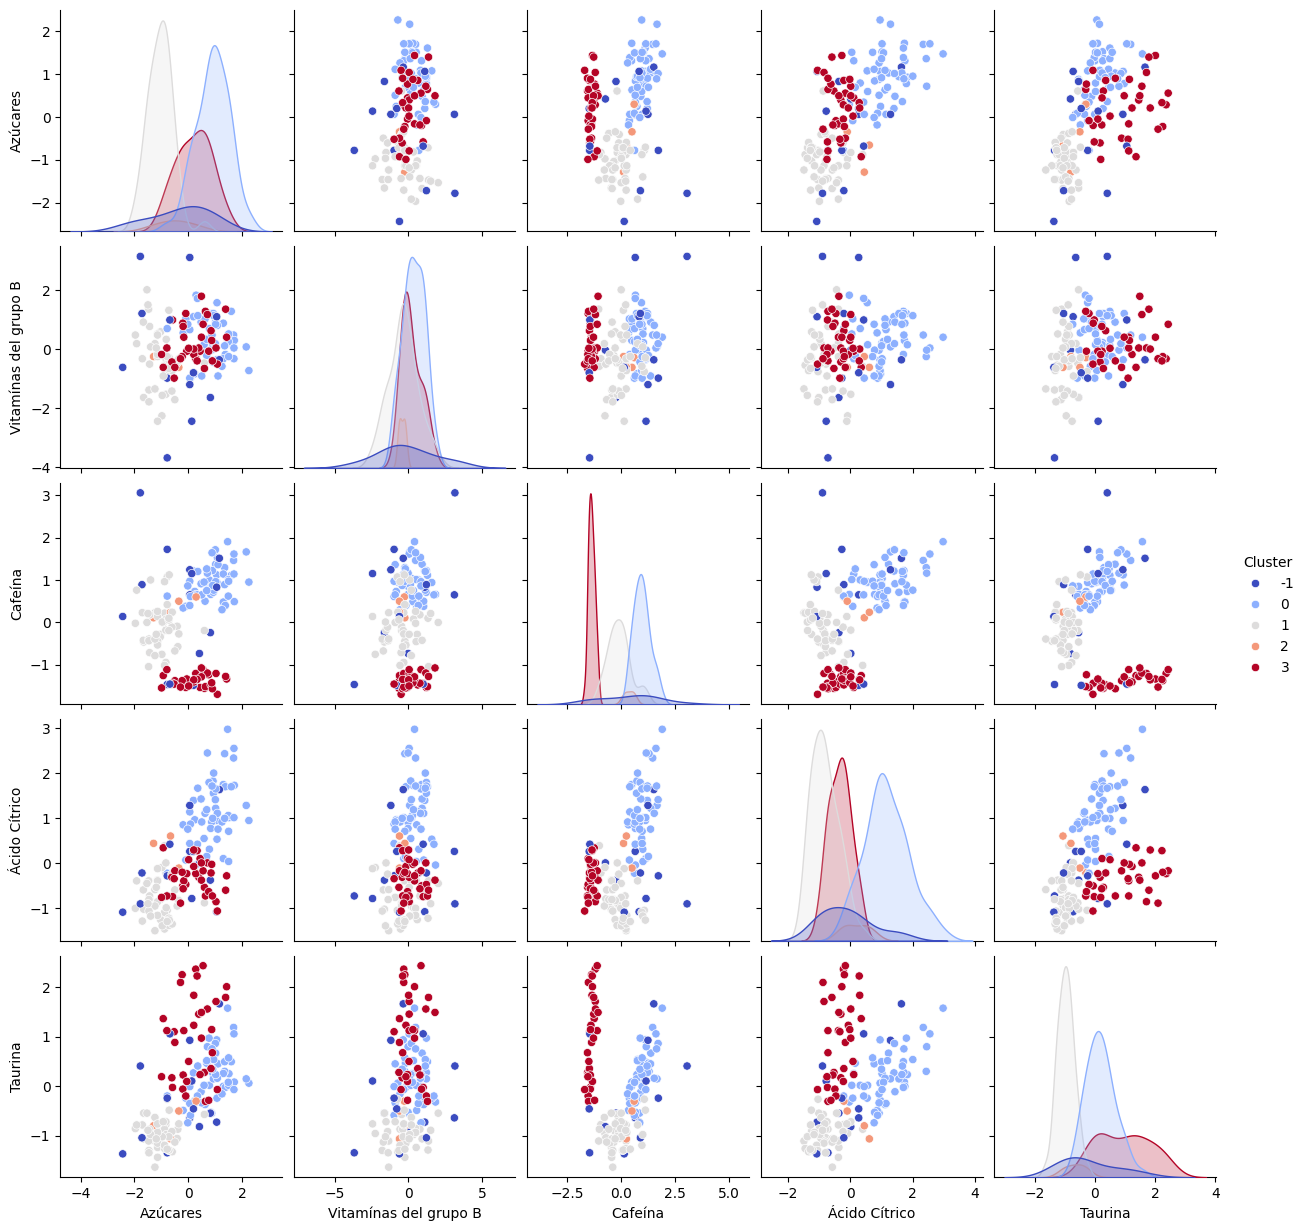

In [19]:
sns.pairplot(train_set_clu, hue = "Cluster", palette="coolwarm");

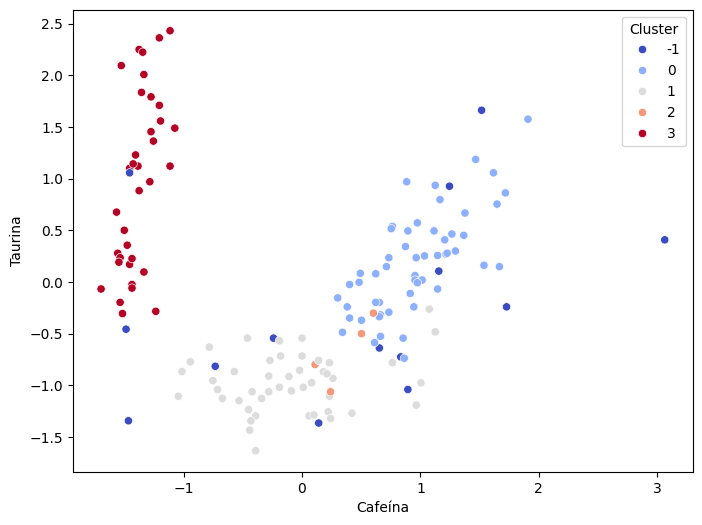

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(data = train_set_clu[["Cafeína","Taurina","Cluster"]], 
                x= "Cafeína", 
                y = "Taurina", 
                hue = "Cluster", 
                palette="coolwarm")

plt.show()

En este gráfico se ve cómo el modelo ha separado los puntos en varios grupos según los valores de cafeína y taurina. Cada color es un grupo distinto, y eso significa que el modelo ha encontrado zonas donde los puntos se parecen entre sí. Por ejemplo, hay un grupo rojo oscuro que está más a la izquierda, donde la cafeína es baja y la taurina es alta, mientras que los grupos azules y el gris están más repartidos por el centro y la derecha con valores más variados. También aparecen puntos que el modelo considera anomalías, que son los que no encajan bien en ningún grupo. 

Voy a probar con las dos variables más representativas del problema, porque igual demasiadas variables entorpecen el modelo

In [21]:
outlier_percent = []
experiments = {}
for min_samples in [3,5,10]:
    print(f"Min_samples = {min_samples}")
    outlier_percent = []
    for eps in np.linspace(0.001,6,100): # Genera 50 valores equidistantes entre 0.001 y 3
        
        # Creamos el modelo
        dbscan = DBSCAN(eps=eps,min_samples=min_samples) # min_samples dos veces el ´numero de features -> 2 por dimensión del hiperespacio en el que representamos el conjunto de puntos... No le des muchas vueltas es un número muy orientativo. Pero piensa que si fuera un recta querrías 2 valores, un plano 4, un cubo 6...
        dbscan.fit(train_set[variables_simples])
        # Registramos el porcentaje de anomalías (recuerda que se etiquetan como -1)
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        #if perc_outliers <= 10:
        #    print(perc_outliers, dbscan.labels_)
        #    print(len(dbscan.labels_))
        #    print(pd.Series(dbscan.labels_).value_counts())
        outlier_percent.append(perc_outliers)
    experiments[min_samples] = outlier_percent.copy()

Min_samples = 3
Min_samples = 5
Min_samples = 10


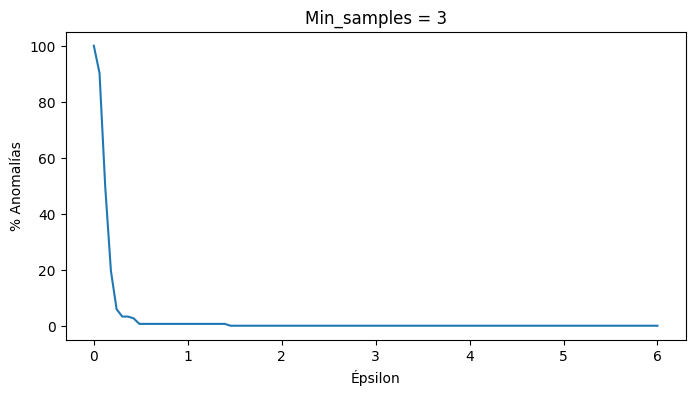

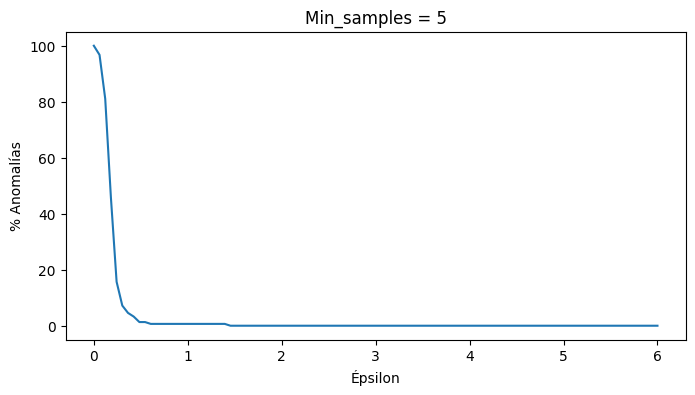

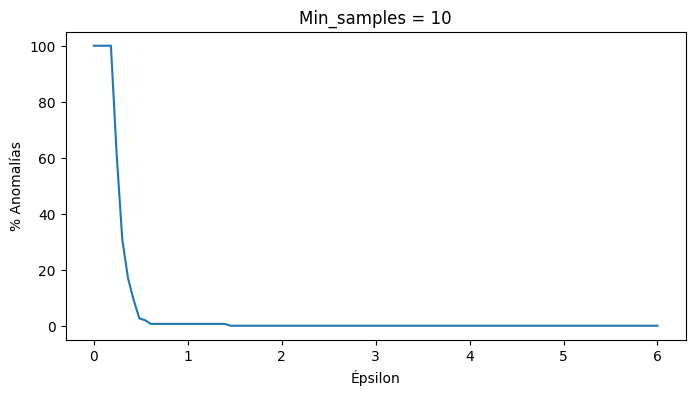

In [22]:
for min_samples in [3,5,10]:
    
    plt.figure(figsize = (8,4), dpi = 100)
    sns.lineplot(x=np.linspace(0.001,6,100),y=experiments[min_samples])
    plt.ylabel("% Anomalías")
    plt.xlabel("Épsilon")
    plt.title(f"Min_samples = {min_samples}")
    plt.show()

In [23]:
for min_samples in [3,5,10]:
    dbscan = DBSCAN(eps = 0.5, min_samples = min_samples)
    dbscan.fit(train_set[variables_simples])
    print(f"{min_samples} = {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters")

3 = 2 clusters
5 = 2 clusters
10 = 2 clusters


In [24]:
for min_samples in [3,5,10]:
    dbscan = DBSCAN(eps = 0.3, min_samples = min_samples)
    dbscan.fit(train_set[variables_simples])
    print(f"{min_samples} = {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters")

3 = 3 clusters
5 = 4 clusters
10 = 3 clusters


In [25]:
pd.Series(dbscan.labels_).value_counts()

 0    51
-1    49
 1    40
 2    13
Name: count, dtype: int64

In [26]:
train_set_simp = pd.DataFrame(train_set).copy()
train_set_simp["Cluster"] = dbscan.labels_

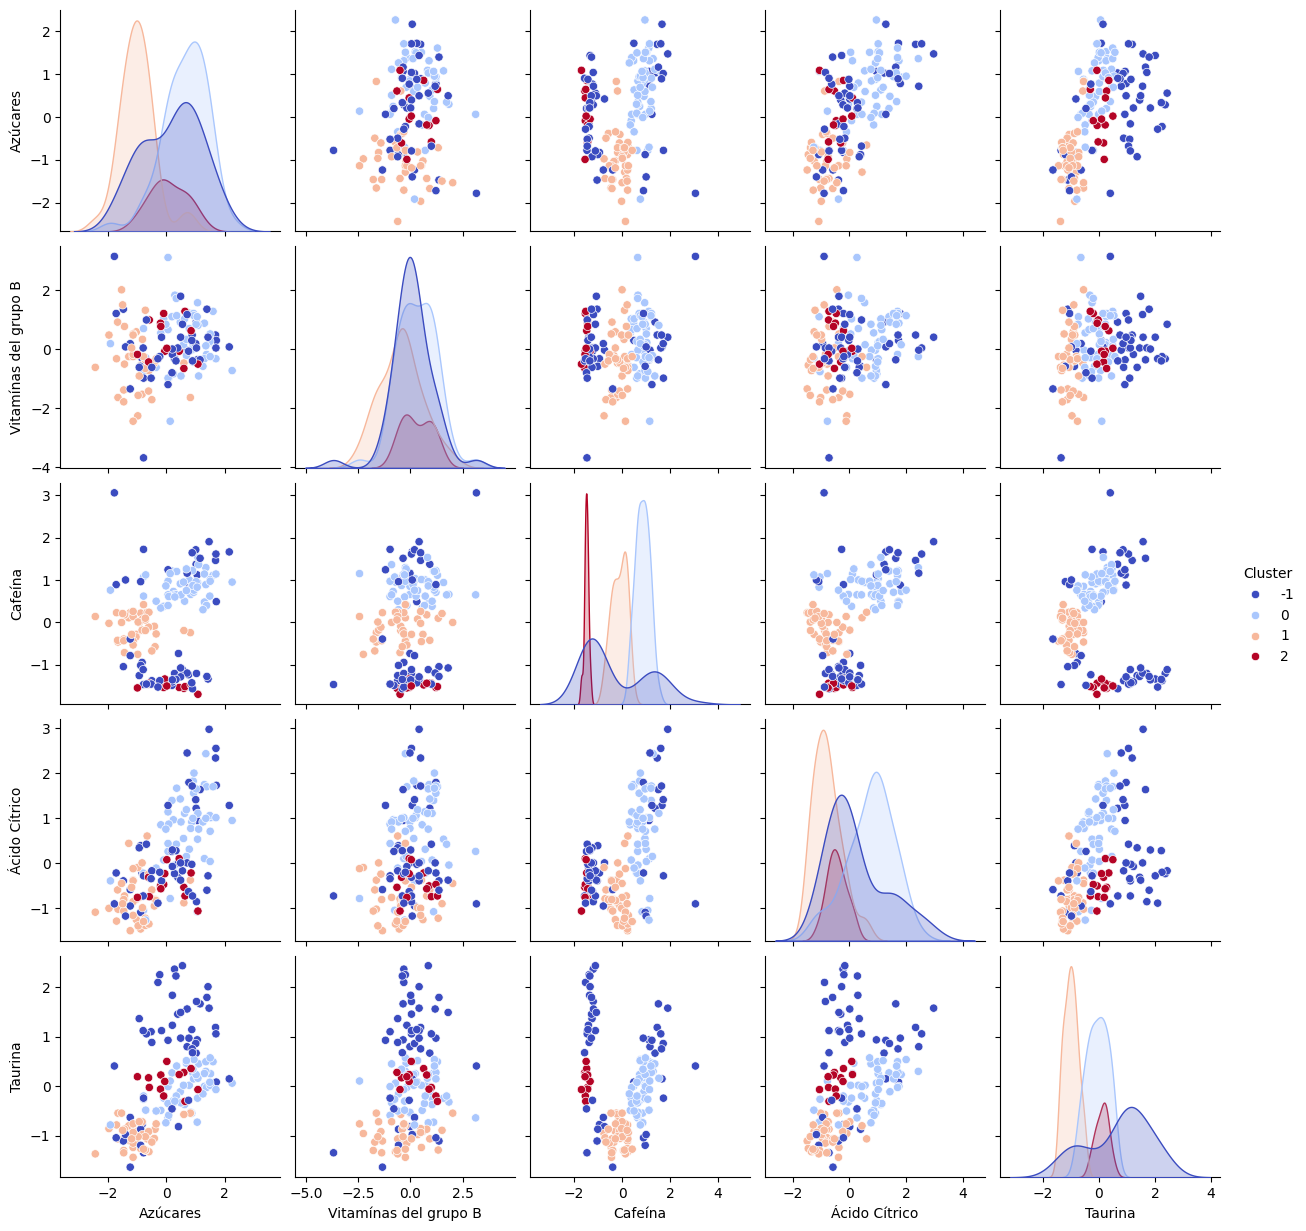

In [27]:
sns.pairplot(train_set_simp, hue = "Cluster", palette="coolwarm");

<Axes: xlabel='Cafeína', ylabel='Taurina'>

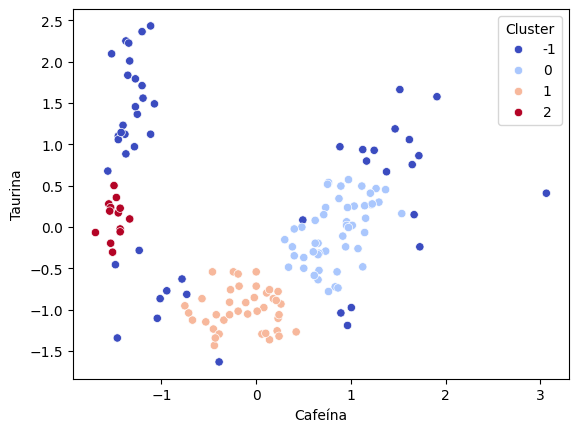

In [28]:
sns.scatterplot(data = train_set_simp, x= "Cafeína", y = "Taurina", hue = "Cluster", palette="coolwarm")

En este cluster se ven muchas anomalías, reduzco el nº de samples

In [29]:
train_set_simp = train_set.copy()

dbscan_3 = DBSCAN(eps = 0.3, min_samples = 3)
dbscan_3.fit(train_set[variables_simples])

train_set_simp["Cluster"] = dbscan_3.labels_

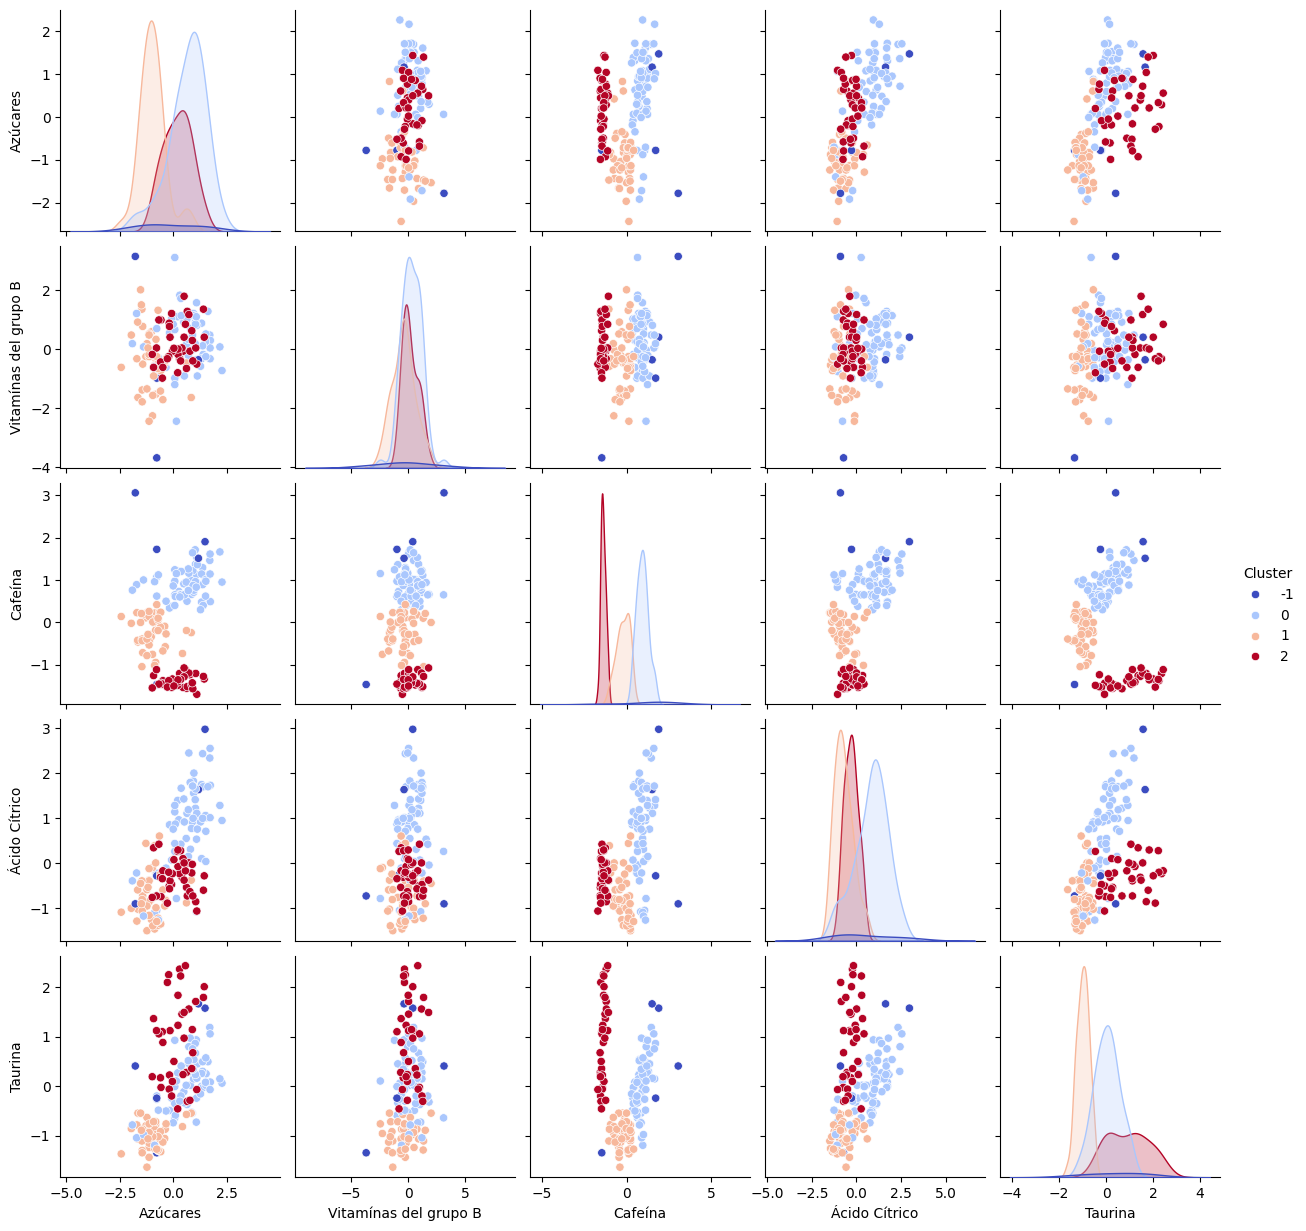

In [30]:
sns.pairplot(train_set_simp, hue = "Cluster", palette="coolwarm");

<Axes: xlabel='Cafeína', ylabel='Taurina'>

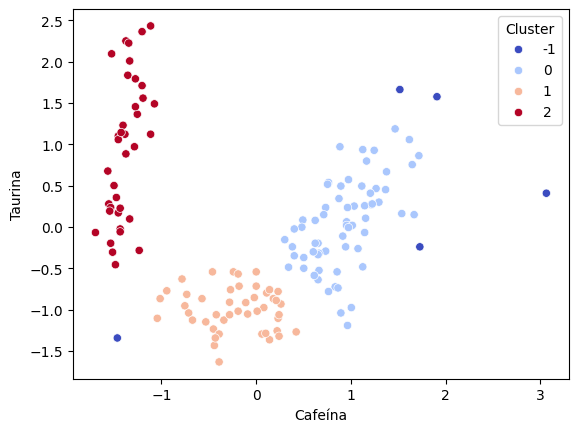

In [31]:
sns.scatterplot(data = train_set_simp, x = "Cafeína", y = "Taurina", hue = "Cluster", palette="coolwarm")

Cambiando el número de samples, se disminuyen las anomalías. Me quedo con lo último

##### JERARQUICO-AGLOMERATIVO

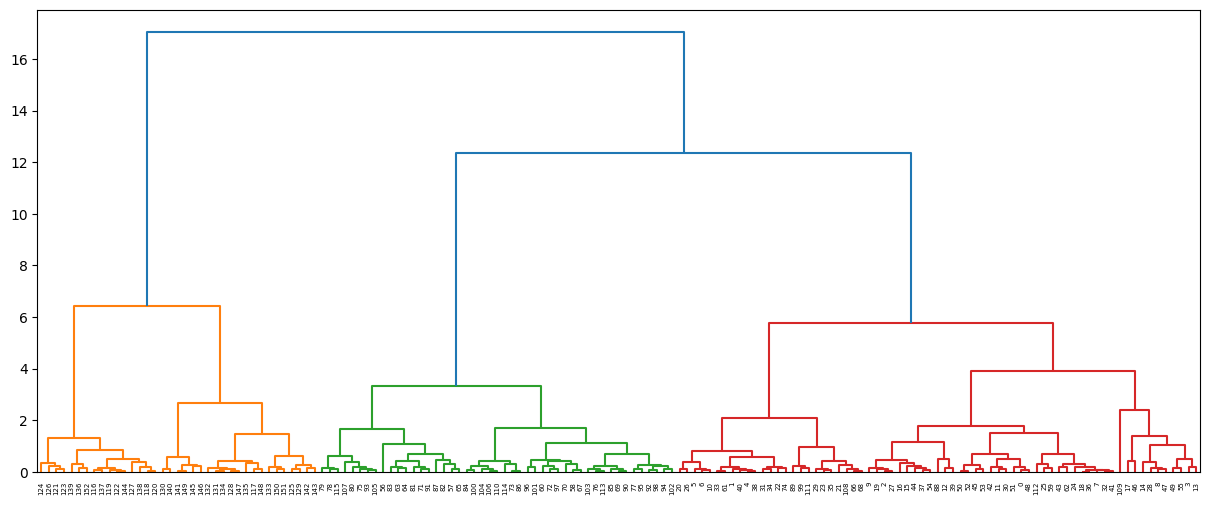

In [32]:
link_method = linkage(train_set[variables_simples], method = 'ward')

plt.figure(figsize =(15,6))
dend = dendrogram(link_method)

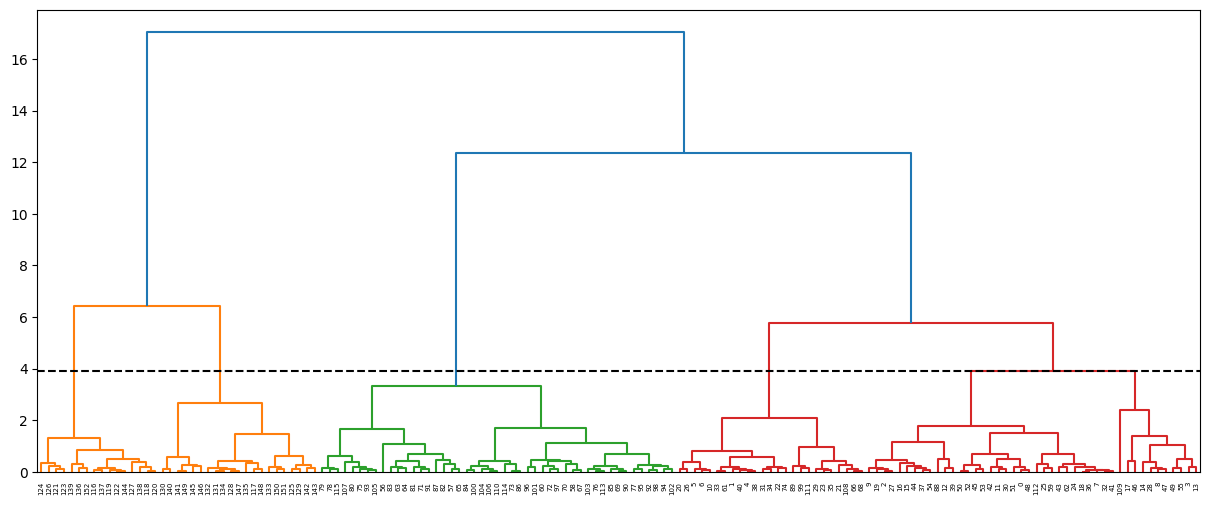

In [33]:
plt.figure(figsize =(15,6))
dend = dendrogram(link_method)
plt.axhline(y = 3.9, color = 'k', linestyle = '--')
plt.show()

In [34]:
modelo_cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

modelo_cluster.fit(train_set[variables_simples])

train_set_3 = train_set.copy()
train_set_3['Cluster'] = modelo_cluster.labels_

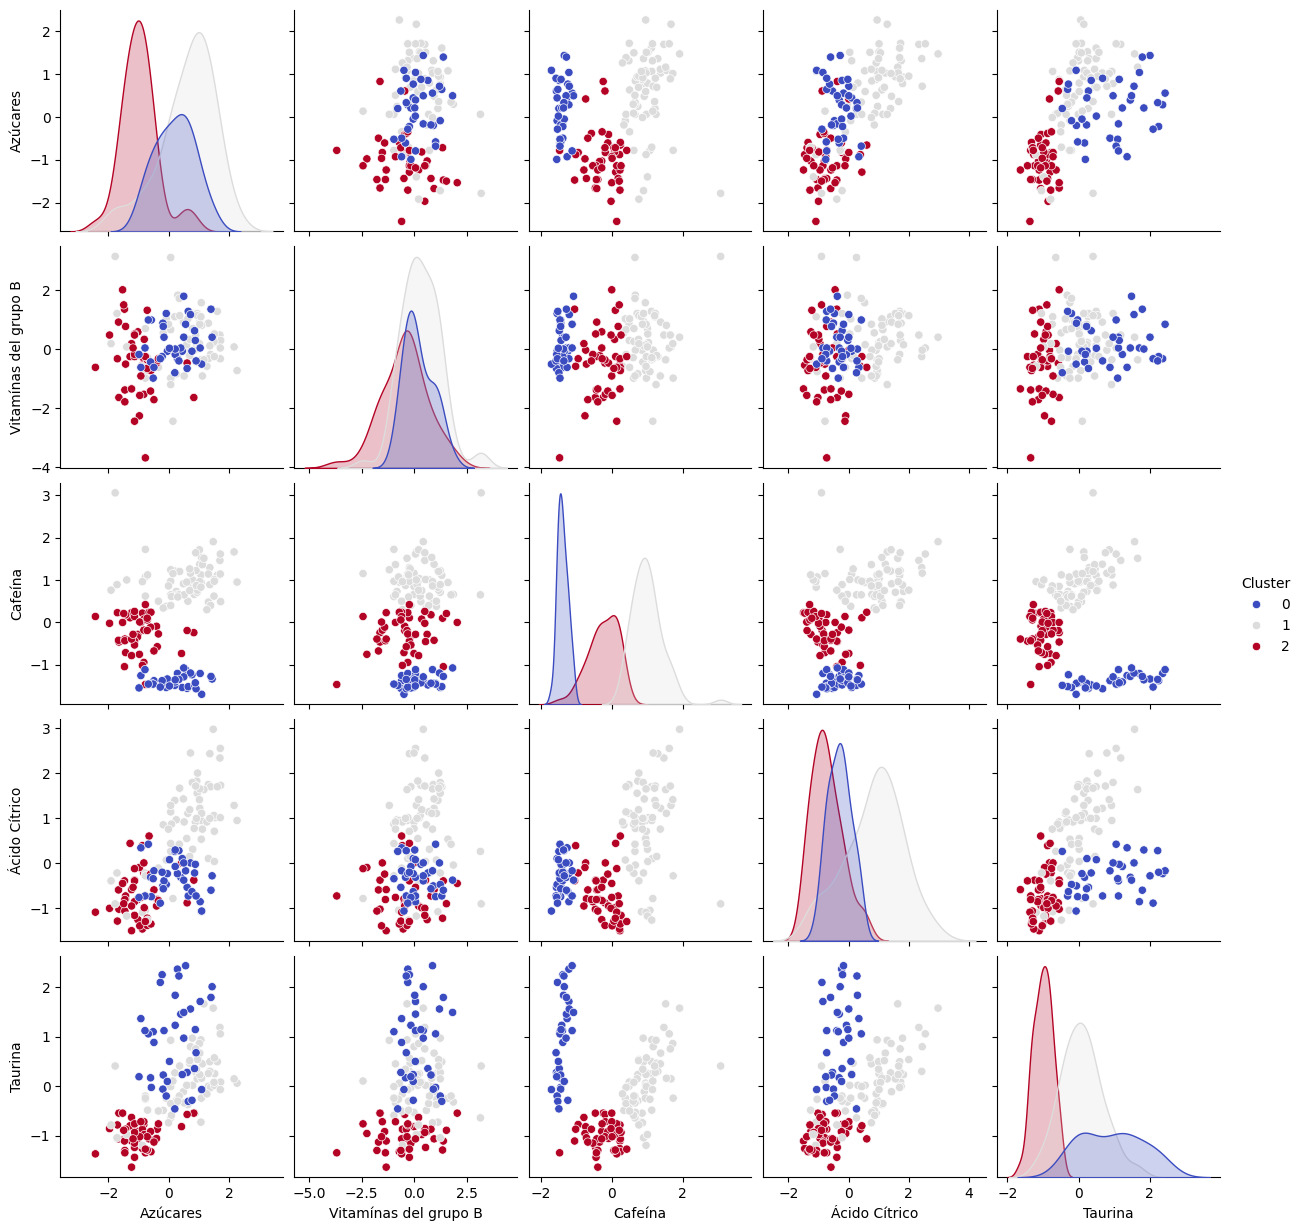

In [35]:
sns.pairplot(train_set_3, hue = "Cluster", palette="coolwarm");

<Axes: xlabel='Cafeína', ylabel='Taurina'>

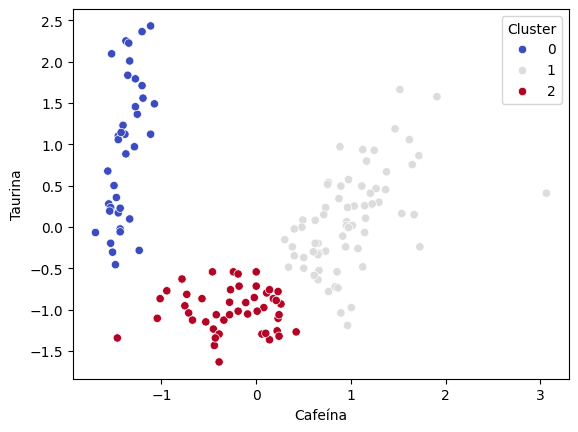

In [36]:
sns.scatterplot(data = train_set_3, x = "Cafeína", y = "Taurina", hue = "Cluster", palette="coolwarm")

Cuando miramos la pareja Taurina–Cafeína en DBSCAN, vemos que los grupos que salen son prácticamente los mismos que en el método aglomerativo. La única diferencia es que DBSCAN sí marca algunos puntos como anomalías, mientras que el aglomerativo mete esos puntos dentro de uno de los tres grupos. Además, podemos fijarnos en los colores del dendrograma para saber a qué grupo pertenece cada punto y ver qué tan separados están unos grupos de otros. Esto sirve para que los químicos puedan valorar si esas diferencias podrían influir en el nivel de “energización” de cada bebida.


##### Distancia entre clusters

In [37]:
modelo_cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [38]:
train_set_3["Cluster"].value_counts()

Cluster
1    69
2    47
0    37
Name: count, dtype: int64

In [39]:
train_set_3.loc[124] # Naranja

Azúcares                 0.765101
Vitamínas del grupo B   -0.060375
Cafeína                 -1.234146
Ácido Cítrico           -0.627005
Taurina                 -0.284670
Cluster                  0.000000
Name: 124, dtype: float64

In [40]:
train_set_3.loc[1] # Rojo

Azúcares                 0.246290
Vitamínas del grupo B   -0.827996
Cafeína                  0.733629
Ácido Cítrico            0.965242
Taurina                 -0.293321
Cluster                  1.000000
Name: 1, dtype: float64

In [41]:
print(f"Naranja: {train_set_3.loc[124]['Cluster']}")
print(f"Verde: {train_set_3.loc[79]['Cluster']}") # Cluster verde
print(f"Rojo: {train_set_3.loc[1]['Cluster']}")

Naranja: 0.0
Verde: 2.0
Rojo: 1.0


Las distancias entre los cluster Verde y Rojo son los que más se parecen entre sí, mientras que Naranja queda bastante más separado.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [42]:
nuevo_train = pd.read_csv("./data/new_experiments.csv", sep = "|")

In [43]:
nuevo_train

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [45]:
modelo_cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

##### Jerárquico

In [46]:
train_II = pd.concat([train_set, nuevo_train])

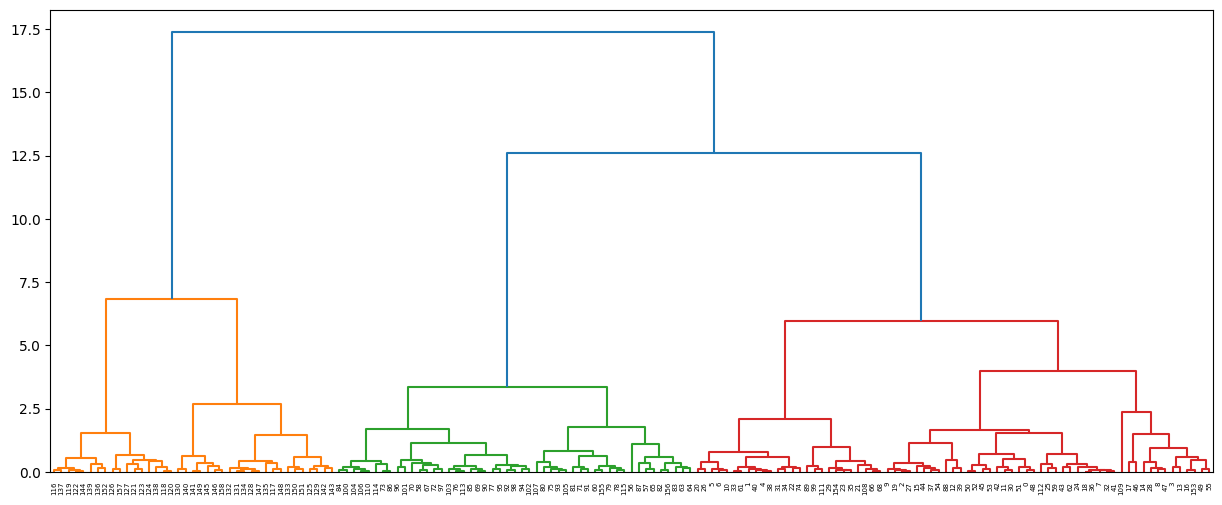

In [47]:
link_method = linkage(train_II[variables_simples], method = 'ward')
plt.figure(figsize =(15,6))
dend = dendrogram(link_method)

In [49]:
modelo_nuevo = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
modelo_nuevo.fit(nuevo_train[variables_simples])

nuevo_train_II = nuevo_train.copy()
nuevo_train_II['Cluster'] = modelo_nuevo.labels_

In [50]:
nuevo_train_II.tail(len(nuevo_train))

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,2
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,2
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,1


### DBSCAN

In [51]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
target = "Cluster"
X_train = train_set_simp.drop(target, axis = 1) 
y_train = train_set_simp[target]


In [52]:
param_grid = {
    "n_neighbors": [2,3,5,10],
    "weights": ["uniform","distance"]
}

knn_grid = GridSearchCV(knn,
                        param_grid = param_grid,
                        cv = 4, 
                        scoring = "balanced_accuracy" 
                        )

knn_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [2, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [53]:
knn_grid.best_params_

{'n_neighbors': 2, 'weights': 'uniform'}

In [54]:
knn_grid.best_score_

np.float64(0.7747395833333334)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_train, knn_grid.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         5
           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        46
           2       1.00      1.00      1.00        37

    accuracy                           1.00       153
   macro avg       1.00      1.00      1.00       153
weighted avg       1.00      1.00      1.00       153



In [56]:
y_pred = knn_grid.best_estimator_.predict(nuevo_train)

In [57]:
nuevo_train["Cluster"] = y_pred

In [58]:
train_set_simp.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster
0,1.518613,0.232053,1.034819,1.013009,0.251717,0
1,0.246290,-0.827996,0.733629,0.965242,-0.293321,0
2,0.196879,1.109334,1.215533,1.395148,0.269020,0
3,1.691550,0.487926,1.466525,2.334574,1.186068,0
4,0.295700,1.840403,0.663351,-0.037874,-0.319276,0


In [59]:
nuevo_train_II.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,2
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,2
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2


In [60]:
print(classification_report(y_test,y_pred))

NameError: name 'y_test' is not defined

No sé qué he hecho mal :(